In [1]:
import pickle as pkl
import random
import numpy as np
import os

In [2]:
import umap
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns

/home/jienihu/miniconda3/envs/slformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]

In [4]:
id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [5]:
res_dir = "/home/jienihu/sc/SLformer/experiment/inference/all_SL"

#### embedding UMAP

In [6]:
def get_emb_cancer(name, cancer, cv=1):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
    # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    ## (5/fold, 2genes/pair, 11727pairs)
    ## emb: (20, 512)
    df = pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv"))
    df_cancer = df[df['cancer']==cancer]
    cancer_idx = df_cancer.index
    emb_gene1 = emb[cv-1][0][cancer_idx,0,:]  ## (datasize, 512)
    emb_gene2 = emb[cv-1][1][cancer_idx,0,:]
    emb_total = np.concatenate([emb_gene1, emb_gene2], axis=0)

    context_cat = df_cancer['cancer'].tolist()*2
    gene1_cat = df_cancer['primary_gene'].tolist()
    gene2_cat = df_cancer['partner_gene'].tolist()
    gene_total = gene1_cat+gene2_cat
    gene_total_df = pd.DataFrame({'gene':gene_total,'context':context_cat})
    ## drop repeated genes
    gene_total_df = gene_total_df.drop_duplicates(keep='first')
    unique_idx = gene_total_df.index
    gene_unique = [gene_total[i] for i in unique_idx]
    emb_unique = emb_total[unique_idx, :]
    context_unique = [context_cat[i] for i in unique_idx]
    
    return gene_unique, emb_unique, context_unique


# def get_emb_cancer(name, cancer):
#     with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
#     # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
#         emb = pkl.load(f)
#     ## (5/fold, 2genes/pair, 11727pairs)
#     ## emb: (20, 512)
#     emb_allcv = []
#     genetotal_allcv = []
#     for cv in range(1,6):
#         df = pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv"))
#         df_cancer = df[df['cancer']==cancer]
#         cancer_idx = df_cancer.index
#         emb_gene1 = emb[cv-1][0][cancer_idx,0,:]  ## (datasize, 512)
#         emb_gene2 = emb[cv-1][1][cancer_idx,0,:]
#         emb_total = np.concatenate([emb_gene1, emb_gene2], axis=0)
#         emb_allcv.append(emb_total)
#         genetotal_allcv.extend(df_cancer['primary_gene'].tolist()+df_cancer['partner_gene'].tolist())

#     gene_total_df = pd.DataFrame({'gene':genetotal_allcv})
#     ## drop repeated genes
#     # gene_total_df = gene_total_df.drop_duplicates(keep='first')
#     unique_idx = gene_total_df.index
#     gene_unique = [genetotal_allcv[i] for i in unique_idx]

#     emb_allcv = np.concatenate(emb_allcv, axis=0)
#     emb_unique = emb_allcv[unique_idx, :]
#     context_unique = [cancer]*len(gene_unique)
    
#     return gene_unique, emb_unique, context_unique

In [7]:
# gene, emb, context = get_emb_cancer("mix_slformer_kg", cancer='all')
## KIRC, COAD, LAML, OV, BRCA, CESC, BRCA, SKCM, LUAD

context_all = []
emb_all = []
gene_all = {}
np.random.seed(0)
for cancer in ['KIRC', 'COAD', 'LAML', 'OV', 'CESC', 'BRCA', 'SKCM', 'LUAD']:
# for cancer in ['KIRC', 'COAD', 'LAML', 'OV', 'CESC', 'BRCA', 'LUAD']:
    # gene, emb, context = get_emb_cancer("mix_slformer_kg", cancer=cancer)
    gene, emb, context = get_emb_cancer("mix_slformer_kg", cancer=cancer, cv=1)
    # if len(emb) > 300:
    #     ## subsampling
    #     sample_indices = np.random.choice(len(emb), size=300, replace=False)
    #     emb_sampled = emb[sample_indices]
    #     context_sampled = [context[i] for i in sample_indices]
    #     gene_sampled = [gene[i] for i in sample_indices]
    #     emb = emb_sampled; context = context_sampled; gene = gene_sampled
    
    print(cancer, emb.shape, len(gene))
    emb_all.append(emb)
    # emb_all.append(emb[:,:256])
    context_all.append(context)
    gene_all[cancer]=gene


KIRC (45, 512) 45
COAD (3940, 512) 3940
LAML (154, 512) 154
OV (39, 512) 39
CESC (113, 512) 113
BRCA (107, 512) 107
SKCM (1986, 512) 1986
LUAD (266, 512) 266


In [8]:
def get_emb_geneformer(gene_cancers):
    with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
        geneformer_emb = pkl.load(f)

    emb_all = []
    context_all = []
    for cancer, gene_list in gene_cancers.items():
        try:
            for g in gene_list:
                g_idx = gene2id_map[g]
                cancer_idx = cancer2id_map[cancer]
                emb_all.append(geneformer_emb[cancer_idx][g_idx])
                context_all.append(cancer)
        except:
            print(f"not found {g}")

    return emb_all, context_all

In [9]:
emb_all = np.concatenate(emb_all, axis=0)
print(emb_all.shape)
context_flatten = [i for sublist in context_all for i in sublist]
print(len(context_flatten))

(6650, 512)
6650


In [10]:
geneformer_emb, geneformer_context = get_emb_geneformer(gene_all)
geneformer_emb = np.stack(geneformer_emb)
print(geneformer_emb.shape, len(geneformer_context))

(6650, 256) 6650


In [11]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

cancers = ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD']
id2cancer = {i:cancer for i,cancer in enumerate(cancers)}

def plot_umap_embeddings(embeddings, labels):
    reducer = umap.UMAP(n_neighbors=30, random_state=0)
    embedding = reducer.fit_transform(embeddings)

    # cmap = cm.tab20(range(19))
    plt.figure(figsize=(10, 8), dpi=300)
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette='tab10',  # Or 'Set1', 'husl', etc. depending on the number of classes
        s=5,
        linewidth=0.3
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(title='Cancer', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_umap_embeddings_3d(embeddings, labels):
    reducer = umap.UMAP(n_neighbors=30, n_components=3, random_state=0)
    embedding = reducer.fit_transform(embeddings)

    fig = plt.figure(figsize=(10, 8), dpi=300)
    ax = fig.add_subplot(111, projection='3d')

    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', n_colors=len(unique_labels))
    label_to_color = {label: palette[i] for i, label in enumerate(unique_labels)}
    colors = [label_to_color[label] for label in labels]

    ax.scatter(
        embedding[:, 0], embedding[:, 1], embedding[:, 2],
        c=colors,
        s=5,
        linewidth=0.3
    )

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_zlabel("UMAP-3")
    
    # Create custom legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=label_to_color[label], markersize=6)
               for label in unique_labels]
    ax.legend(handles=handles, title='Cancer', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


/home/jienihu/miniconda3/envs/slformer/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


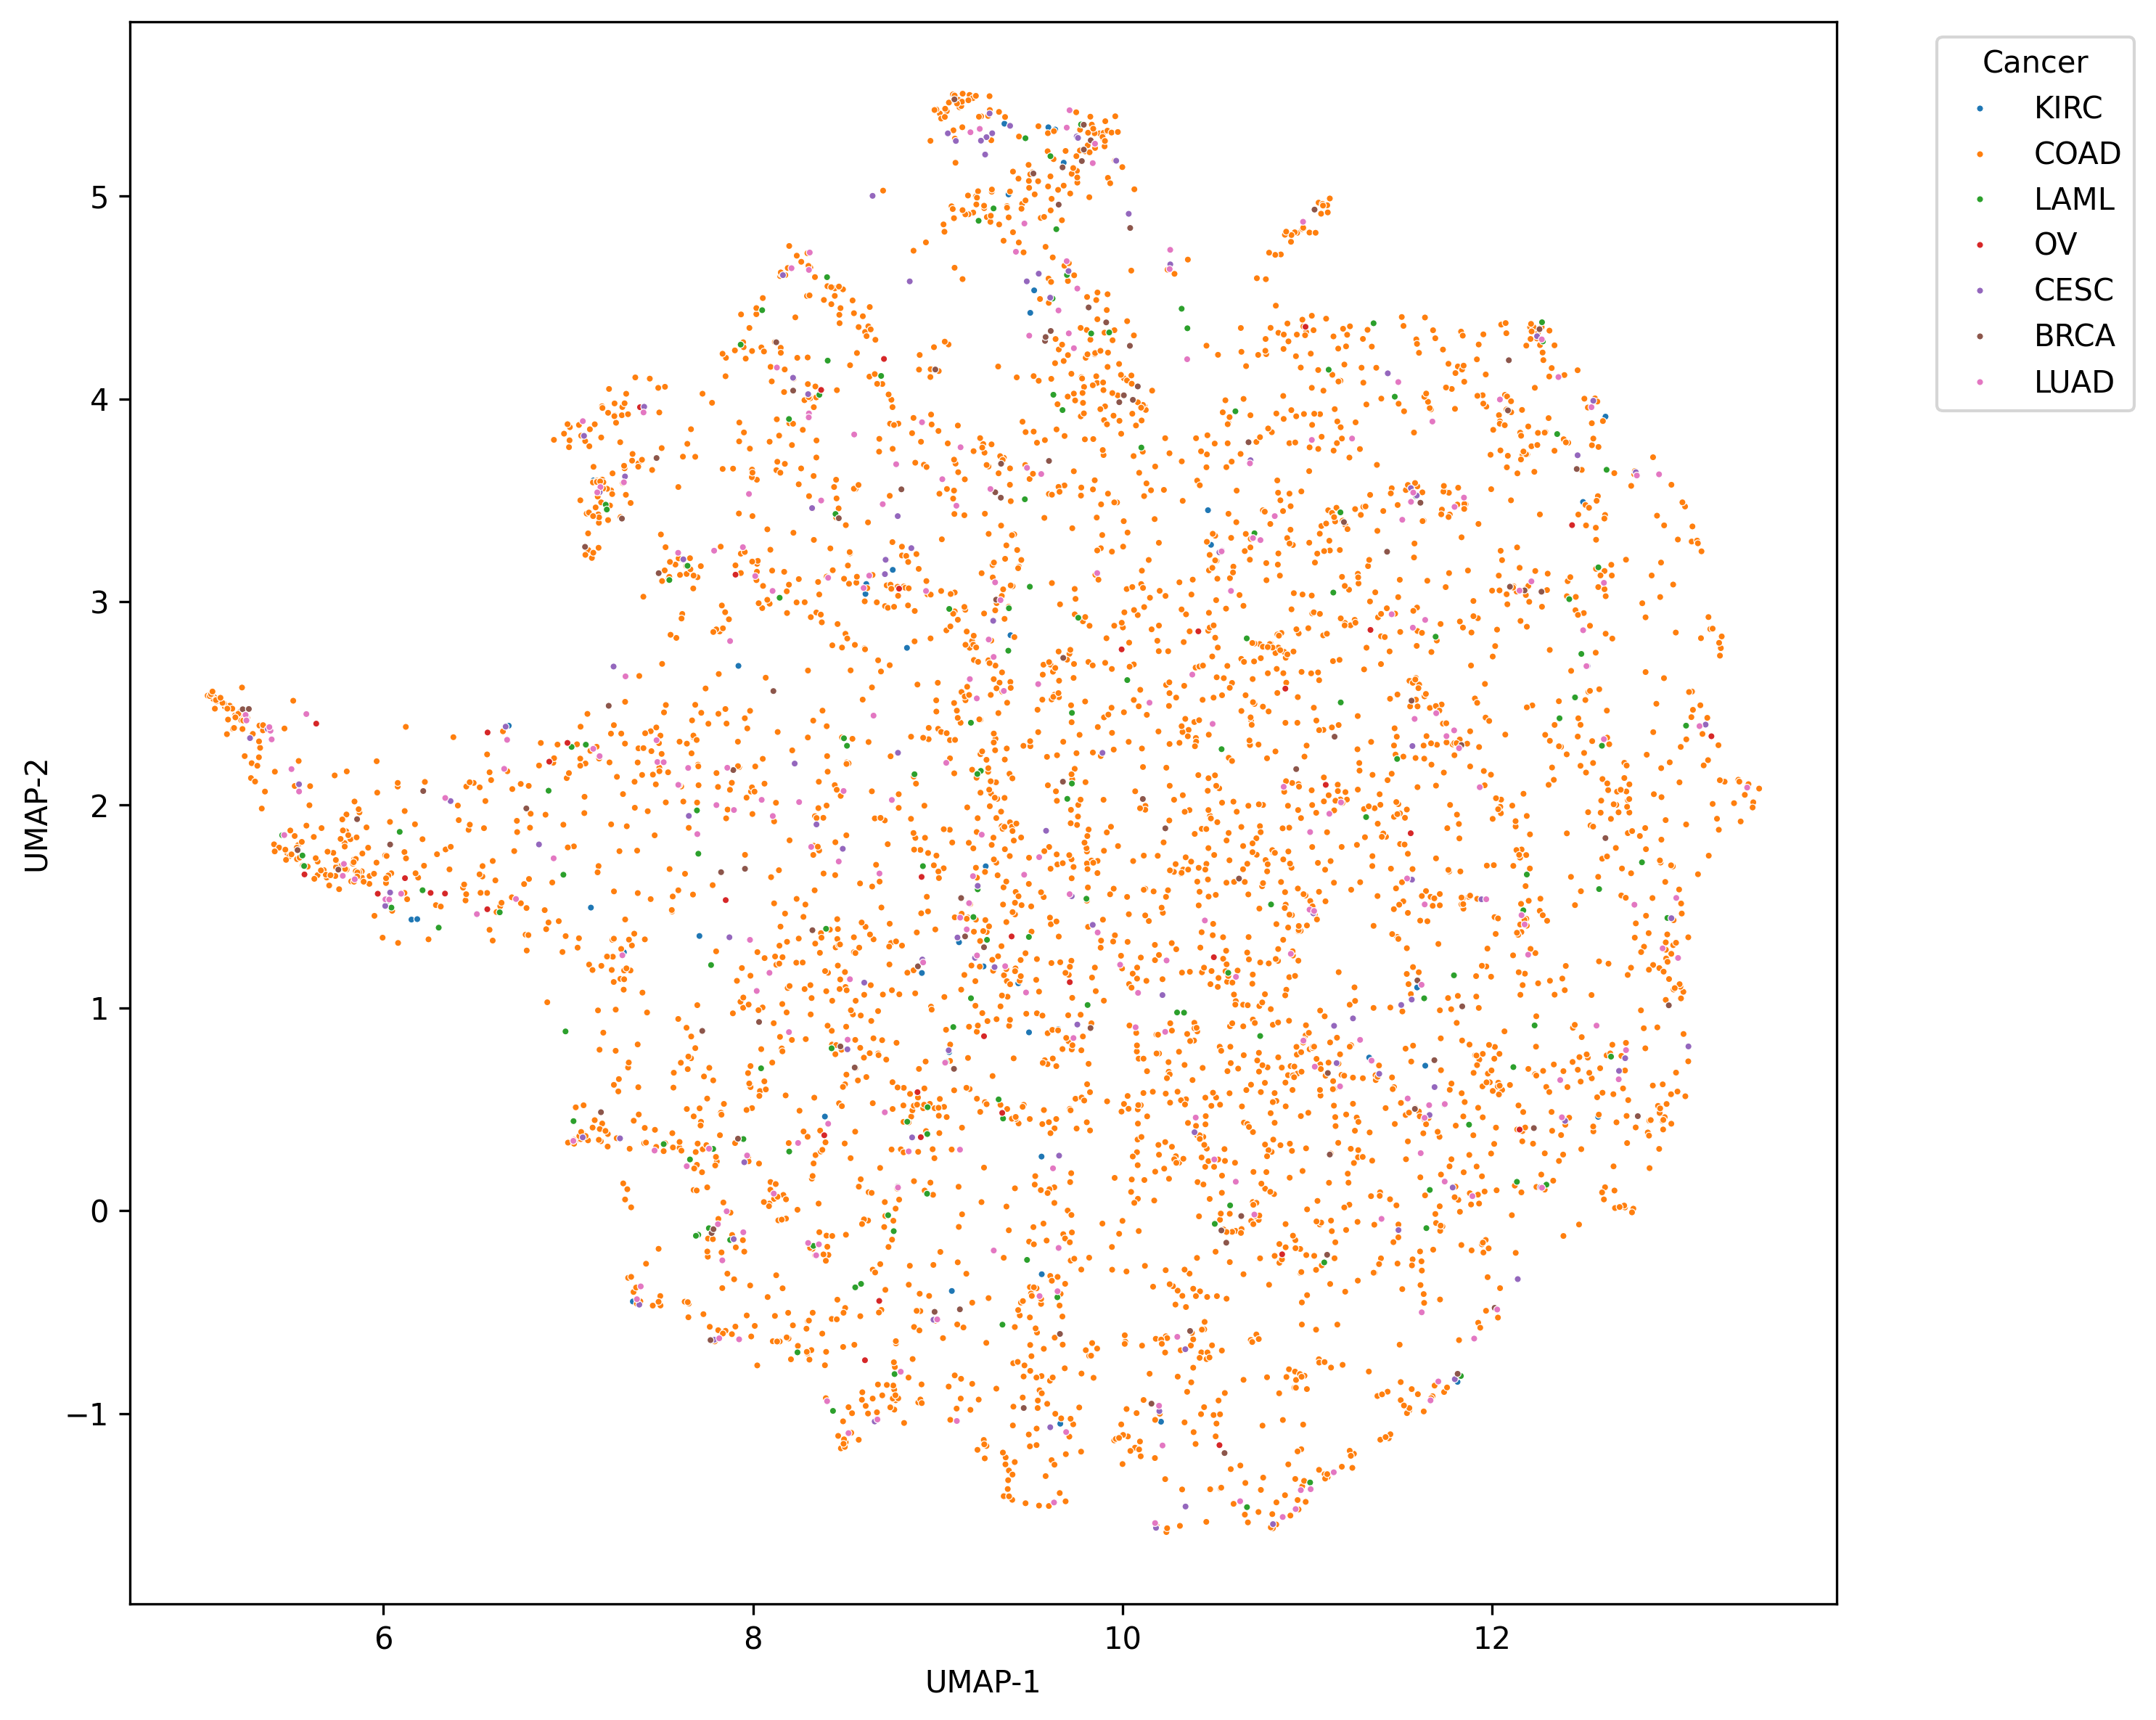

In [12]:
plot_umap_embeddings(emb_all, context_flatten)
# plot_umap_embeddings_3d(emb_all, context_flatten)

In [70]:
plot_umap_embeddings(geneformer_emb, geneformer_context)

/home/jienihu/miniconda3/envs/slformer/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


KeyboardInterrupt: 

#### Simple classifier for context

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, random_split
from collections import defaultdict
import numpy as np

In [13]:
## inputs
print(emb_all.shape)
## targets
print(len(context_flatten))

(6650, 512)
6650


In [14]:
len(set(context_flatten))

8

In [33]:
# Encode string labels to integers
le = LabelEncoder()
context_labels = le.fit_transform(context_flatten)

class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [59]:
device = torch.device("cuda:0")
# ----- MLP Model -----
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, output_dim=10):
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# ----- Training Loop with Early Stopping -----
# def evaluate(model, loader):
#     model.eval()
#     model.to(device)
#     correct = total = 0
#     with torch.no_grad():
#         for X_batch, y_batch in loader:
#             X_batch = X_batch.to(device); y_batch = y_batch.to(device)
#             outputs = model(X_batch)
#             preds = outputs.argmax(dim=1)
#             correct += (preds == y_batch).sum().item()
#             total += y_batch.size(0)
#     return correct / total

# from collections import defaultdict
# import numpy as np

def evaluate(model, loader, num_classes=8):
    model.eval()
    model.to(device)
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(torch.float32)
            X_batch = X_batch.to(device); y_batch = y_batch.to(device)
            logits = model(X_batch)
            preds = logits.argmax(dim=1)

            for true_label, pred_label in zip(y_batch, preds):
                total_per_class[int(true_label)] += 1
                if true_label == pred_label:
                    correct_per_class[int(true_label)] += 1

    # Compute per-class accuracy
    class_accuracies = {}
    for cls in range(num_classes):
        total = total_per_class[cls]
        correct = correct_per_class[cls]
        acc = correct / total if total > 0 else float("nan")
        class_accuracies[cls] = acc

    return class_accuracies

In [60]:
def train_classifier(model, train_loader, val_loader, optimizer, criterion):
    best_val_acc = 0
    patience = 5
    counter = 0
    num_epochs = 50

    for epoch in range(num_epochs):
        model.train()
        model.to(device)
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(torch.float32)
            X_batch = X_batch.to(device); y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        # val_acc = evaluate(model, val_loader)
        # print(f"Epoch {epoch+1}, Validation Accuracy: {val_acc:.4f}")
        class_accuracies = evaluate(model, val_loader)
        avg_acc = np.mean(list(class_accuracies.values()))
        print(f"Epoch {epoch+1} | Per-class Validation Accuracy:")
        # Optional: label decoding
        for cls_idx, acc in class_accuracies.items():
            class_name = le.inverse_transform([cls_idx])[0]
            print(f"  {class_name} (class {cls_idx}): {acc:.4f}")
        print("avg accuracy", avg_acc)

        # Early stopping
        if avg_acc > best_val_acc:
            best_val_acc = avg_acc
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Load the best model
    model.load_state_dict(best_model_state)

    return model

In [36]:
## slformer emb
dataset = SimpleDataset(emb_all, context_labels)
## split into train and val
val_ratio = 0.2
val_size = int(len(dataset)*val_ratio)
train_size = len(dataset)-val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

model = MLPClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_classifier(model, train_loader, val_loader, optimizer, criterion)

Epoch 1 | Per-class Validation Accuracy:
  BRCA (class 0): 0.1667
  CESC (class 1): 0.0400
  COAD (class 2): 0.9899
  KIRC (class 3): 1.0000
  LAML (class 4): 0.0690
  LUAD (class 5): 0.0469
  OV (class 6): 0.0000
  SKCM (class 7): 0.9974
avg accuracy 0.4137307458242904
Epoch 2 | Per-class Validation Accuracy:
  BRCA (class 0): 0.1111
  CESC (class 1): 0.0000
  COAD (class 2): 0.9899
  KIRC (class 3): 1.0000
  LAML (class 4): 0.0690
  LUAD (class 5): 0.2344
  OV (class 6): 0.0000
  SKCM (class 7): 0.9974
avg accuracy 0.42522380137984594
Epoch 3 | Per-class Validation Accuracy:
  BRCA (class 0): 0.2778
  CESC (class 1): 0.0000
  COAD (class 2): 0.9749
  KIRC (class 3): 1.0000
  LAML (class 4): 0.4483
  LUAD (class 5): 0.3594
  OV (class 6): 0.1000
  SKCM (class 7): 0.9974
avg accuracy 0.5197115057060748
Epoch 4 | Per-class Validation Accuracy:
  BRCA (class 0): 0.3889
  CESC (class 1): 0.4000
  COAD (class 2): 0.9598
  KIRC (class 3): 1.0000
  LAML (class 4): 0.3448
  LUAD (class 5): 0.

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [57]:
print(geneformer_emb.shape, len(geneformer_context))
le = LabelEncoder()
geneformer_context_labels = le.fit_transform(geneformer_context)
dataset = SimpleDataset(geneformer_emb, geneformer_context_labels)

(6650, 256) 6650


In [61]:
## geneformer emb
print(geneformer_emb.shape, len(geneformer_context))
le = LabelEncoder()
geneformer_context_labels = le.fit_transform(geneformer_context)
dataset = SimpleDataset(geneformer_emb, geneformer_context_labels)
## split into train and val
val_ratio = 0.2
val_size = int(len(dataset)*val_ratio)
train_size = len(dataset)-val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

model = MLPClassifier(input_dim=256)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_classifier(model, train_loader, val_loader, optimizer, criterion)

(6650, 256) 6650


Epoch 1 | Per-class Validation Accuracy:
  BRCA (class 0): 0.0000
  CESC (class 1): 0.0000
  COAD (class 2): 0.9924
  KIRC (class 3): 0.0000
  LAML (class 4): 0.0000
  LUAD (class 5): 0.0000
  OV (class 6): 0.0000
  SKCM (class 7): 0.9975
avg accuracy 0.24873895992092593
Epoch 2 | Per-class Validation Accuracy:
  BRCA (class 0): 0.0000
  CESC (class 1): 0.0000
  COAD (class 2): 0.9924
  KIRC (class 3): 0.0000
  LAML (class 4): 0.0000
  LUAD (class 5): 0.0000
  OV (class 6): 0.0000
  SKCM (class 7): 0.9975
avg accuracy 0.24873895992092593
Epoch 3 | Per-class Validation Accuracy:
  BRCA (class 0): 0.0588
  CESC (class 1): 0.0000
  COAD (class 2): 0.9887
  KIRC (class 3): 0.0000
  LAML (class 4): 0.4483
  LUAD (class 5): 0.0200
  OV (class 6): 0.0000
  SKCM (class 7): 0.9975
avg accuracy 0.3141540916645814
Epoch 4 | Per-class Validation Accuracy:
  BRCA (class 0): 0.0000
  CESC (class 1): 0.0000
  COAD (class 2): 0.9899
  KIRC (class 3): 0.0000
  LAML (class 4): 0.5172
  LUAD (class 5): 0

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

#### embedding similarity

In [6]:
def get_emb(name, cancer):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
    # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    ## (5/fold, 2genes/pair, 11727pairs)
    ## emb: (20, 512)
    
    if emb[0][0].ndim == 2:
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    gene_total_df = pd.DataFrame({'gene':gene_total,'context':context_cat})
    gene_total_df = gene_total_df.drop_duplicates(keep='first')
    unique_idx = gene_total_df.index

    # gene_norep = list(set(gene_total))
    # gene_norep.sort()
    # unique_idx = [i for i,g in enumerate(gene_total) if g not in gene_norep[:i]]
    gene_unique = [gene_total[i] for i in unique_idx]
    emb_unique = emb_total[unique_idx, :]
    context_unique = [context_cat[i] for i in unique_idx]

    return gene_unique, emb_unique, context_unique
    

In [7]:
def cos_sim(A,B):
    dot_product = np.dot(A, B)

    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    cosine_similarity = dot_product / (norm_A * norm_B)

    return cosine_similarity


def calc_sim(gene, emb, context, n_sample=50):
    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
    np.random.seed(1)
    cos_sim_all = []
    
    for g in gene_selected:
        gene_df = gene_context_df[gene_context_df['gene']==g]
        idx = gene_df.index
        for i in range(len(gene_df)):
            for j in range(i+1, len(gene_df)):
                cos_sim_all.append({
                    'gene': g,
                    'cancer1': gene_df['context'][idx[i]],
                    'cancer2': gene_df['context'][idx[j]],
                    'cos_sim': cos_sim(emb[idx[i]], emb[idx[j]])
                })
                # cos_sim_all.append(cos_sim(emb[idx[i]], emb[idx[j]]))

    return gene_selected, pd.DataFrame(cos_sim_all)

def calc_sim_geneformer(gene_selected):
    with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    try:
        for g in gene_selected:
            g_idx = gene2id_map[g]
            for i in range(8):
                for j in range(i+1,8):
                    cos_sim_all.append({
                        'gene': g,
                        'cancer1': id2cancer_map[i],
                        'cancer2': id2cancer_map[j],
                        'cos_sim': cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx])
                    })
                    # cos_sim_all.append(cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx]))
    except:
        print(f"not found {g_idx}")

    return pd.DataFrame(cos_sim_all)


In [8]:
gene, emb, context = get_emb("mix_slformer_kg", cancer='all')
gene_selected, cos_sim_all_kg = calc_sim(gene, emb, context)

In [9]:
gene, emb, context = get_emb("mix_slformer_nokg", cancer='all')
gene_selected, cos_sim_all_nokg = calc_sim(gene, emb, context)

In [10]:
cos_sim_geneformer = calc_sim_geneformer(gene_selected)

not found 6623


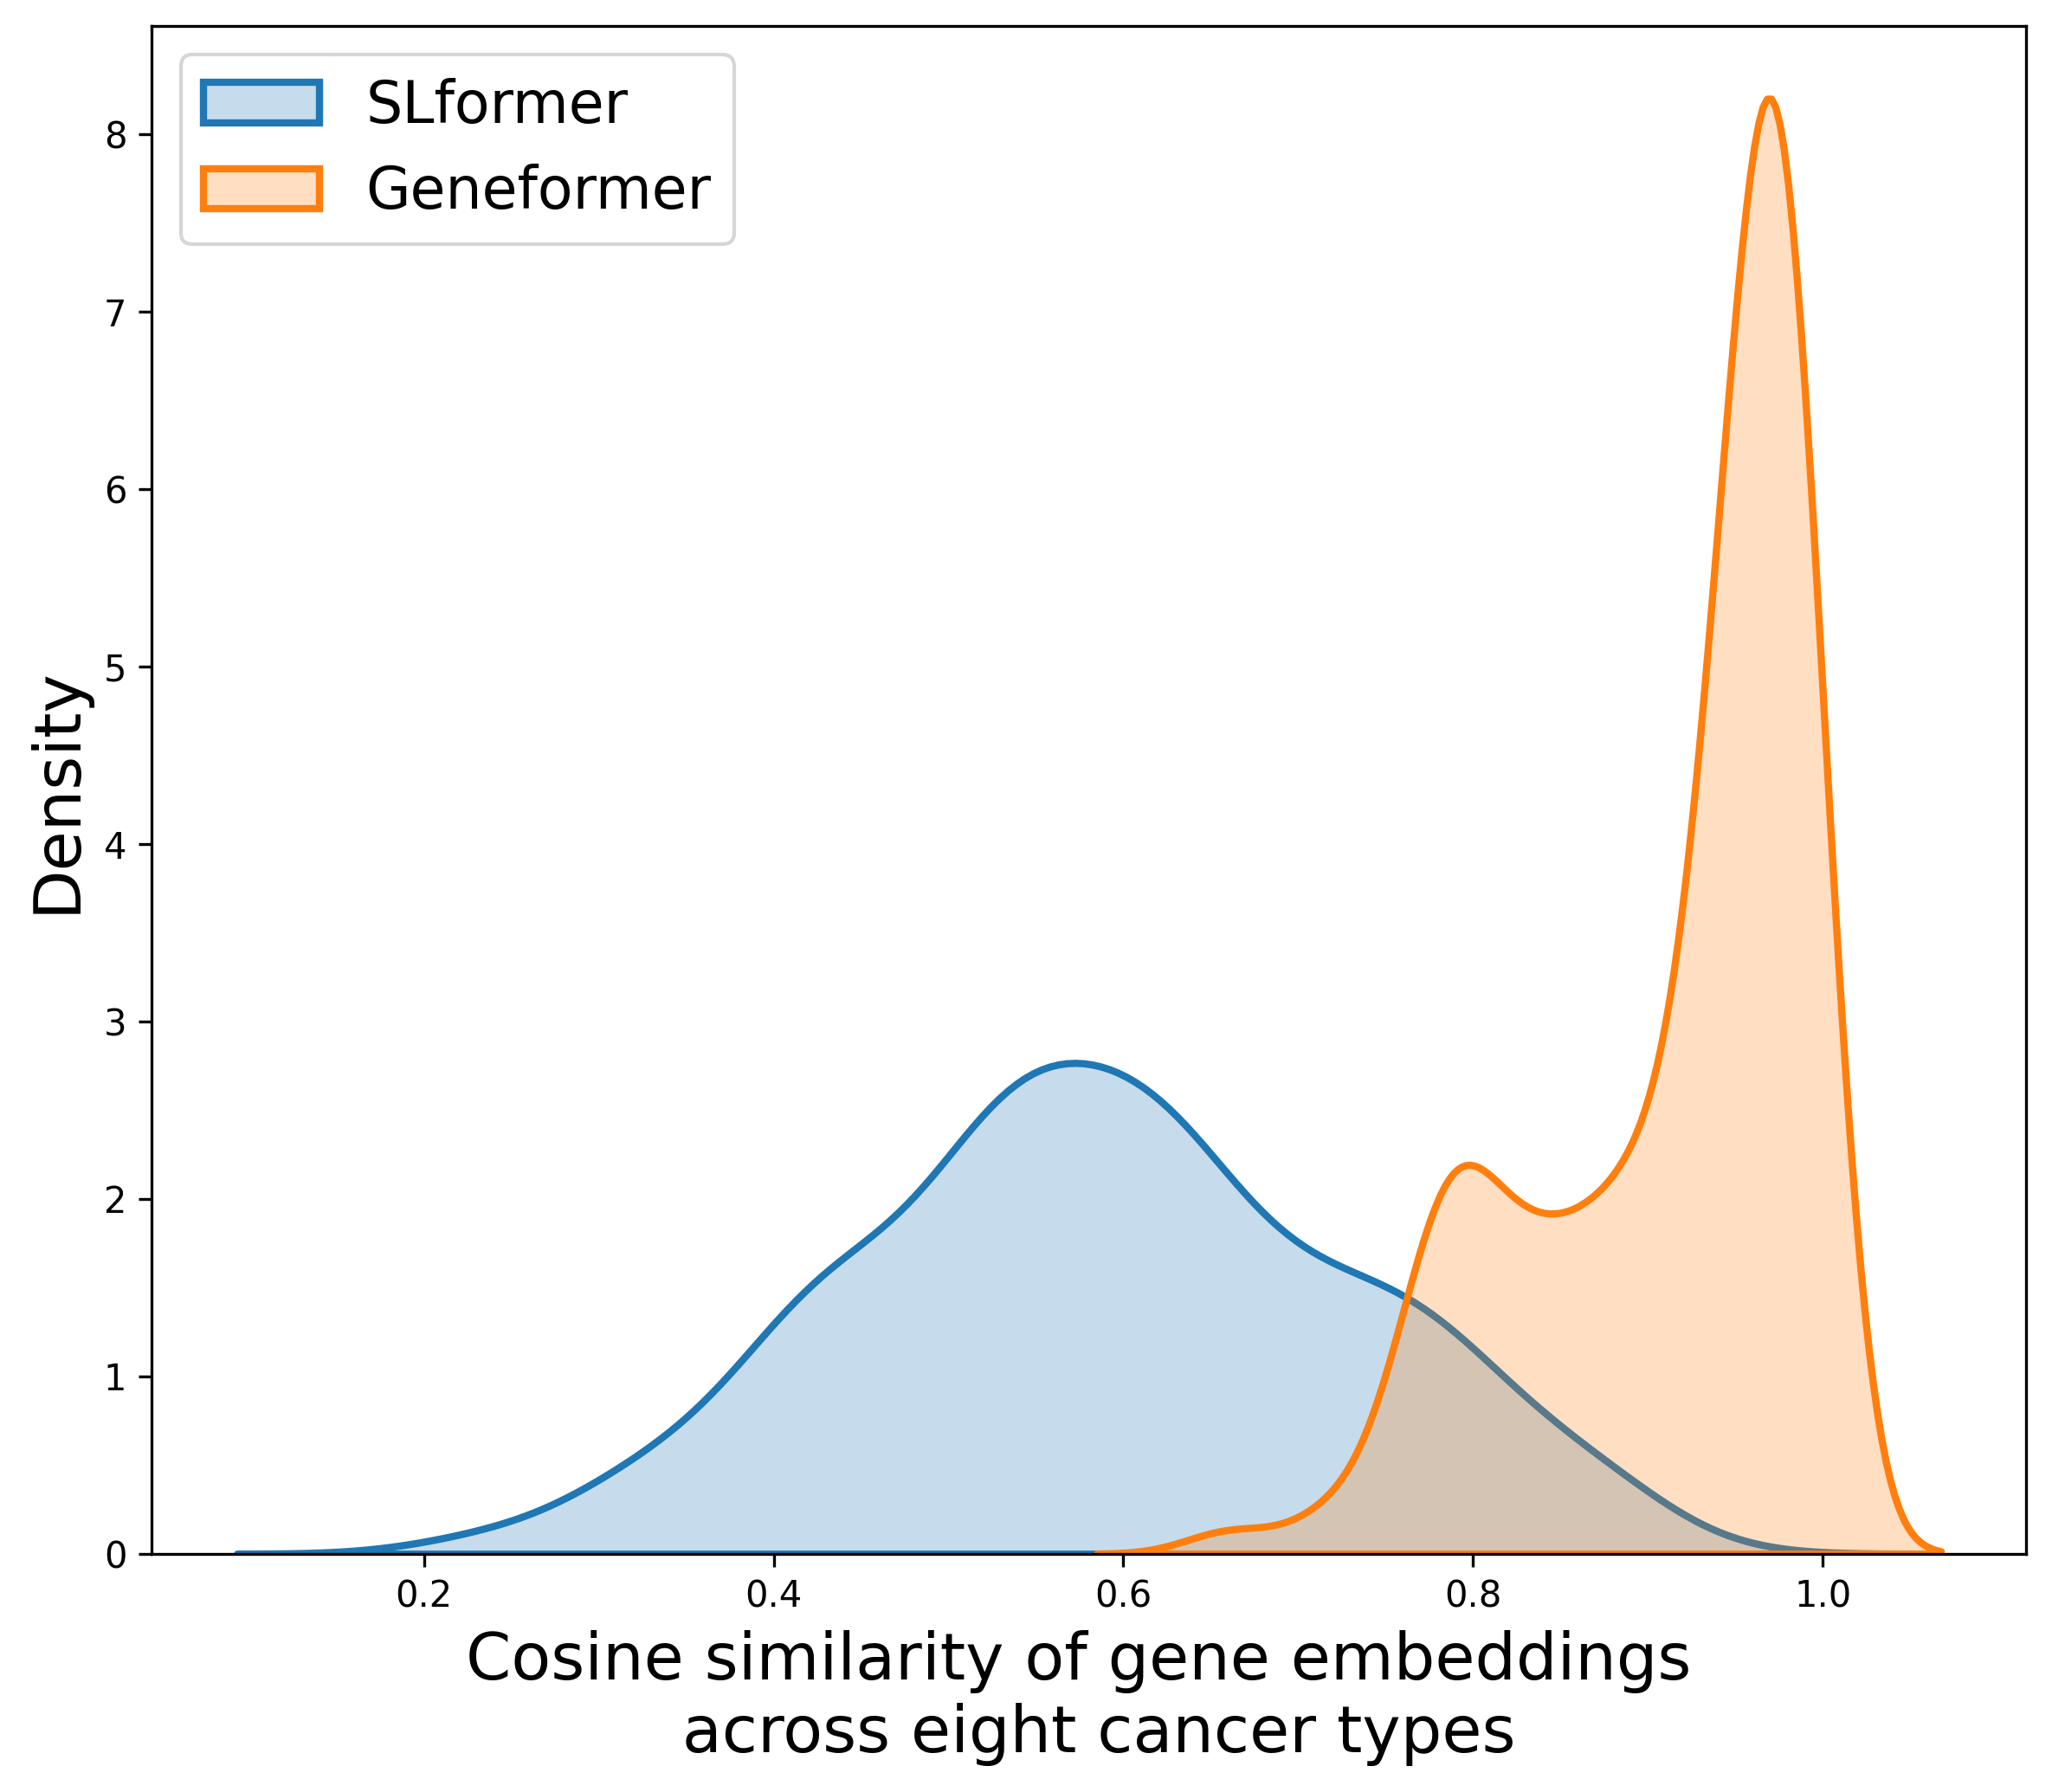

In [11]:
bins = 30
plt.figure(figsize=(8, 7), dpi=300)

sns.kdeplot(cos_sim_all_kg['cos_sim'], fill=True, linewidth=2, label='SLformer') ## color=''
# sns.kdeplot(cos_sim_all_nokg['cos_sim'], label='SLformer after training (noKG)')
sns.kdeplot(cos_sim_geneformer['cos_sim'], fill=True, linewidth=2, label='Geneformer')

plt.legend(loc='upper left', fontsize=16)
plt.xlabel('Cosine similarity of gene embeddings \n across eight cancer types', 
           fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.tight_layout()
plt.savefig("./emb_diff_context.pdf", dpi=300, bbox_inches='tight')
plt.show()

#### functional similarity

In [21]:
from goatools.obo_parser import GODag
from goatools.associations import read_gaf

go_dag = GODag("/home/jienihu/sc/SLformer/data/GO/go-basic.obo")
annotations = read_gaf("/home/jienihu/sc/SLformer/data/GO/goa_human.gaf", go_dag=go_dag)

/home/jienihu/sc/SLformer/data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:16.486282 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [22]:
id_mapping = pd.read_csv("/home/jienihu/sc/SLformer/data/GO/idmapping_2024_11_09.tsv", sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))

In [23]:
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

In [24]:
len(anno_mapped.keys())

17575

In [25]:
def find_shared_goterms(gene1, gene2):

    go_terms_gene1 = {go_id for go_id in anno_mapped.get(gene1, [])}
    go_terms_gene2 = {go_id for go_id in anno_mapped.get(gene2, [])}

    shared_go_terms = go_terms_gene1.intersection(go_terms_gene2)

    return len(shared_go_terms)


def pairs_shared_goterms(df):

    ngoterm_all = []

    for i in range(len(df)):
        gene1 = df['gene1'][i]
        gene2 = df['gene2'][i]
        nshared_go_terms = find_shared_goterms(gene1, gene2)
        ngoterm_all.append(nshared_go_terms)

    return ngoterm_all


In [26]:
def calc_sim_genes(gene, emb, context, n_sample=50):

    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    context_all = list(set(gene_context_df['context']))
    context_all.sort()
    np.random.seed(1)
    cos_sim_all = []

    for cancer in context_all:
        df_cancer = gene_context_df[gene_context_df['context']==cancer]
        df_pairs = [df_cancer.sample(2, random_state=i, replace=False) for i in range(n_sample)]

        for pairs in df_pairs:
            idx = pairs.index
            cos_sim_all.append({
                'gene1': pairs['gene'].iloc[0],
                'gene2': pairs['gene'].iloc[1],
                'context': cancer,
                'cos_sim': cos_sim(emb[idx[0]], emb[idx[1]])
            })
        
    return pd.DataFrame(cos_sim_all)


def calc_sim_genes_geneformer(df):
    with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    for i, row in df.iterrows():
        try:
            cancer_idx = cancer2id_map[row['context']]
            g1_idx = gene2id_map[row['gene1']]
            g2_idx = gene2id_map[row['gene2']]
            cos_sim_all.append({
                'gene1': row['gene1'],
                'gene2': row['gene2'],
                'context': row['context'],
                'cos_sim': cos_sim(geneformer_emb[cancer_idx][g1_idx], geneformer_emb[cancer_idx][g2_idx])
            })
            # cos_sim_all.append(cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx]))
        except:
            print(f"not found genes")

    return pd.DataFrame(cos_sim_all)

In [27]:
gene, emb, context = get_emb("mix_slformer_kg", cancer='all')
cos_sim_all_kg = calc_sim_genes(gene, emb, context, n_sample=5000)

In [28]:
gene, emb, context = get_emb("mix_slformer_nokg", cancer='all')
cos_sim_all_nokg = calc_sim_genes(gene, emb, context, n_sample=5000)

In [29]:
cos_sim_all_geneformer = calc_sim_genes_geneformer(cos_sim_all_kg)

In [30]:
nshared_go_terms = pairs_shared_goterms(cos_sim_all_kg)

In [31]:
cos_sim_all_kg['nshared_go_terms'] = nshared_go_terms
# cos_sim_all_nokg['nshared_go_terms'] = nshared_go_terms
cos_sim_all_geneformer['nshared_go_terms'] = nshared_go_terms

cos_sim_all_kg = cos_sim_all_kg.sort_values(by='nshared_go_terms', ascending=False)
# cos_sim_all_nokg = cos_sim_all_nokg.sort_values(by='nshared_go_terms', ascending=False)
cos_sim_all_geneformer = cos_sim_all_geneformer.sort_values(by='nshared_go_terms', ascending=False)

In [32]:
cos_sim_all_kg = cos_sim_all_kg.drop_duplicates(keep='first')
# cos_sim_all_nokg = cos_sim_all_nokg.drop_duplicates(keep='first')
cos_sim_all_geneformer = cos_sim_all_geneformer.drop_duplicates(keep='first')

In [46]:
def plot_func_sim_allcancer(df, savename, go_thr=3):

    plt.figure(figsize=(8, 3.5), dpi=300)
    
    df_high = df[df['nshared_go_terms']>=go_thr]
    df_low = df[df['nshared_go_terms']==0]
    df_low = df_low.iloc[-len(df_high):,:]  ## gene pairs with the least number of shared GO terms

    sns.kdeplot(df_high['cos_sim'], fill=True, linewidth=2, label='gene pairs with similar functions', color='#1CE17F')
    sns.kdeplot(df_low['cos_sim'], fill=True, linewidth=2, label='gene pairs with dissimilar functions', color='#FA512F')

    # plt.title(title, fontsize=15)
    plt.xlabel('Cosine Similarity of pairs of gene embeddings \n in the same cancer', 
               fontsize=16)
    plt.ylabel('Density', fontsize=16)
    plt.legend(fontsize=12)
    plt.savefig(f"./{savename}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


# def plot_func_sim_allcancer(df, savename, go_thr=3):

#     plt.figure(figsize=(14, 6), dpi=300)
    
#     df_high = df[df['nshared_go_terms']>=go_thr]
#     df_low = df[df['nshared_go_terms']<go_thr]
    
#     df_low = df_low.sample(n=len(df_high), random_state=0)
    
#     sns.kdeplot(df_high['cos_sim'], fill=True, linewidth=2, label='gene pairs with similar functions', color='#1CE17F')
#     sns.kdeplot(df_low['cos_sim'], fill=True, linewidth=2, label='gene pairs with dissimilar functions', color='#FA512F')

#     # plt.title(title, fontsize=15)
#     plt.xlabel('Cosine Similarity of pairs of gene embeddings in the same cancer', fontsize=18)
#     plt.ylabel('Density', fontsize=18)
#     plt.legend(fontsize=14)
#     # plt.title(title, fontsize=18)
#     plt.show()

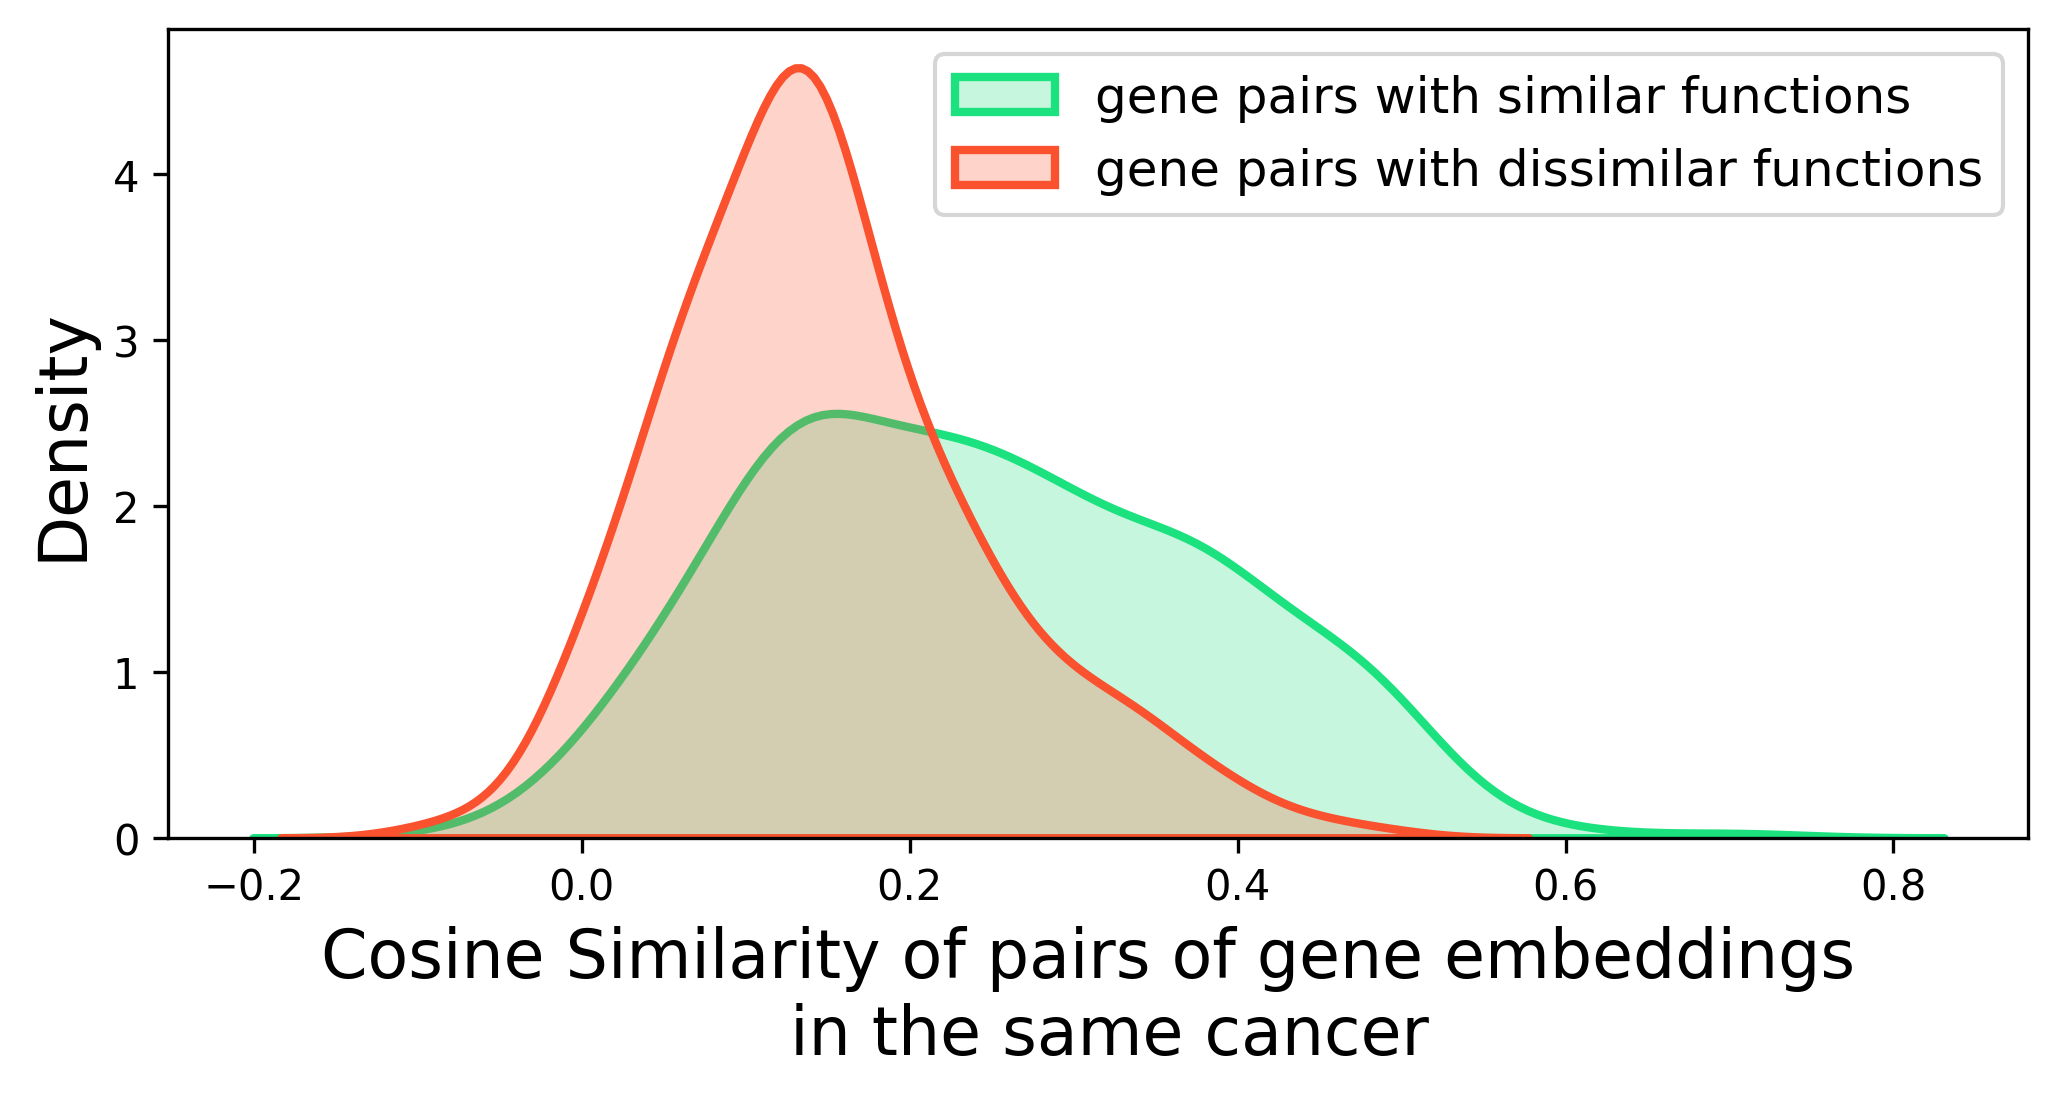

In [47]:
plot_func_sim_allcancer(cos_sim_all_kg, savename="emb_diff_func_trained_slformer", go_thr=5)

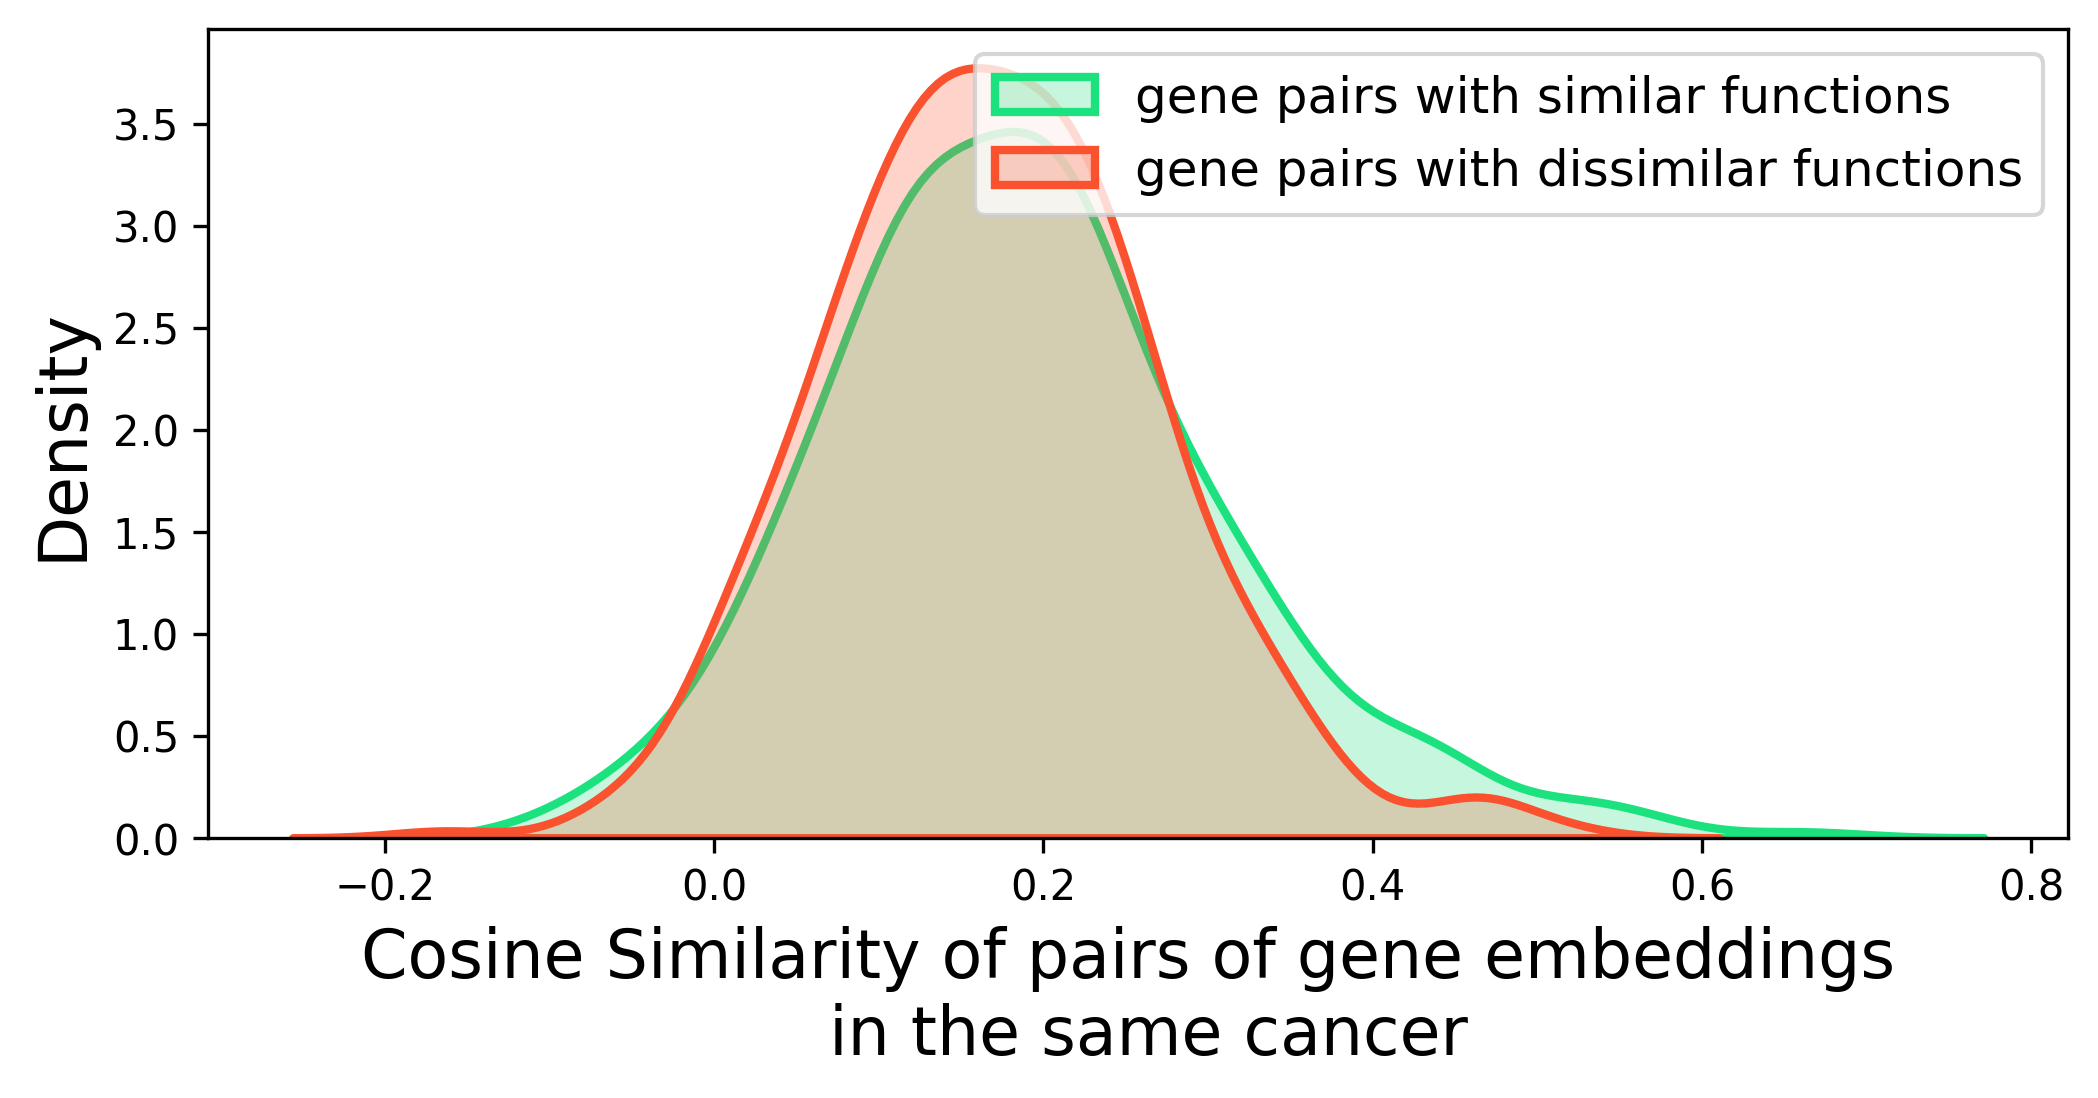

In [48]:
plot_func_sim_allcancer(cos_sim_all_geneformer, savename="emb_diff_func_pretrained_geneformer", go_thr=5)